# import dependencies

In [7]:
from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

# Load data  

In [8]:
student_performance = fetch_ucirepo('Student Performance')
X= student_performance.data.features
y = student_performance.data.targets['G3'] # we select the third final grade


##### encode the categorical (string) data to numeric 

In [11]:
categorical_col = X.select_dtypes(include=['object']).columns
X= pd.get_dummies(X, columns = categorical_col, drop_first= True)

In [12]:
X_train , X_test , y_train , y_test = train_test_split(X, y , test_size= 0.2, random_state=42)

In [13]:
# Scale the fetaures 
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.fit_transform(X_test)

# Build and Compile the model

In [16]:
model = Sequential([
    Dense(32 , activation='relu' , input_shape=(X_train.shape[1],)),
    Dense(64, activation= 'relu'),
    Dense(1, activation= 'linear')
])

In [17]:
#compile the model
model.compile(
    optimizer= 'adam',
    loss='mean_squared_error',
    metrics=['mae']
)

In [18]:
#early stoping :Keras callback that monitors training and stops it automatically when things stop improving.
early_stop =EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights= True
)

# Train the model

In [19]:
histpry = model.fit(X_train , y_train , validation_split = 0.2, epochs=200,
                    batch_size =32 , callbacks= [early_stop], verbose= 1)

Epoch 1/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 64ms/step - loss: 148.8653 - mae: 11.7296 - val_loss: 141.5791 - val_mae: 11.5900
Epoch 2/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 126.8101 - mae: 10.7760 - val_loss: 119.8425 - val_mae: 10.6015
Epoch 3/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 104.1822 - mae: 9.7010 - val_loss: 95.8733 - val_mae: 9.3838
Epoch 4/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 79.2549 - mae: 8.3381 - val_loss: 69.2311 - val_mae: 7.7860
Epoch 5/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 53.7095 - mae: 6.6157 - val_loss: 43.2237 - val_mae: 5.8327
Epoch 6/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 32.2402 - mae: 4.8075 - val_loss: 24.3180 - val_mae: 4.1842
Epoch 7/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 20.8436 - mae: 3.6705 - val_loss: 14.8263 - val_mae: 3.1973
Epoch 8/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 15.2089 - mae: 3.0722 - val_loss: 11.6941 - val_mae: 2.7532
Epoch 9/200
13/13 ━━━━━━━━━━━━━

In [20]:
#evaluate the model 
loss , mae = model.evaluate(X_test, y_test , verbose =2)
print(f"Test MAE : {mae:.2f}")

5/5 - 0s - 25ms/step - loss: 10.2367 - mae: 2.4072
Test MAE : 2.41


In [21]:
predictions = model.predict(X_test)
print(predictions[:5])

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step 
[[12.513803]
 [13.316083]
 [13.017228]
 [10.022461]
 [10.205904]]


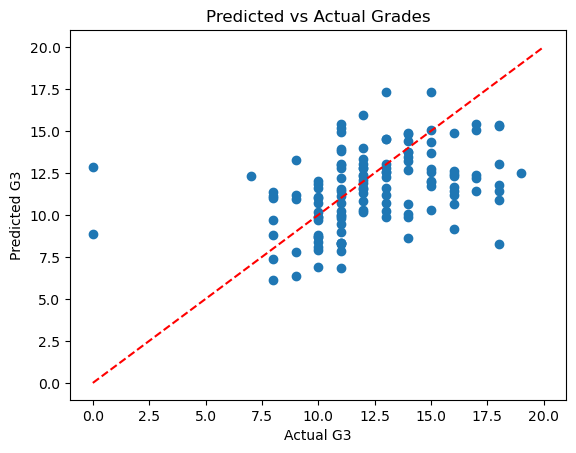

In [22]:
import matplotlib.pyplot as plt

plt.scatter(y_test, predictions)
plt.xlabel("Actual G3")
plt.ylabel("Predicted G3")
plt.title("Predicted vs Actual Grades")
plt.plot([0, 20], [0, 20], 'r--')  # perfect prediction line
plt.show()


#### from predicting values to classes 

In [25]:
threshold =10
predicted_classes = np.where(predictions >= threshold , "pass" , "fail")
print(predicted_classes[:10])

[['pass']
 ['pass']
 ['pass']
 ['pass']
 ['pass']
 ['pass']
 ['pass']
 ['pass']
 ['pass']
 ['pass']]


In [28]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse = mean_squared_error(y_test, predictions)
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("MSE:", mse)
print("MAE:", mae)
print("R2:", r2)


MSE: 10.236737251281738
MAE: 2.407158374786377
R2: -0.049736976623535156


# Save and Reload the model

In [30]:
model.save("student_performance_model.keras")

In [32]:
#load the model again
from tensorflow.keras.models import load_model
loaded_model = load_model("student_performance_model.keras", compile=False)


In [33]:
prediction = loaded_model.predict(X_test)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step 
